In [22]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


filename = Path.cwd().parent / "Datasets" / "Clariti Consumption" / "LMS_2013-01-01_2026-03-24_HALF_HOUR_au.pq"
df = pd.read_parquet(filename, engine='fastparquet')
df.columns = df.columns.str.replace(" consumption", "")

# Remove NMIs 6102507141 and VAAA003225
print("Original number of NMIs: " + str(len(df.columns)-1))
df.drop(columns=["6102507141","VAAA003225"], inplace=True)

df['date'] = pd.to_datetime(df['date'])
df.sort_values(by='date', ascending=True)

# Enrolment data (EFTSL = Equivalent Full-Time Student Load)
enrolment_lookup = pd.DataFrame({
    'year': list(range(2013, 2025)),
    'total_eftsl': [
        40445,   # 2013
        42653,   # 2014
        45431,   # 2015
        48088,   # 2016
        50220,   # 2017
        52676,   # 2018
        54714,   # 2019
        52165,   # 2020
        54396,   # 2021
        52709,   # 2022
        53964,   # 2023
        57931,   # 2024
    ],
    'international_eftsl': [
        11705,   # 2013
        13193,   # 2014
        15211,   # 2015
        17567,   # 2016
        19988,   # 2017
        22438,   # 2018
        23948,   # 2019
        21468,   # 2020
        21810,   # 2021
        21840,   # 2022
        24027,   # 2023
        26875,   # 2024
    ],
})

Original number of NMIs: 101


In [24]:
# Derived columns: for domestic students, and international share
enrolment_lookup['domestic_eftsl'] = (
    enrolment_lookup['total_eftsl'] - enrolment_lookup['international_eftsl']
)
enrolment_lookup['intl_share'] = (
    enrolment_lookup['international_eftsl'] / enrolment_lookup['total_eftsl']
)

# Index relative to 2019 (last pre-COVID year)
b_total = enrolment_lookup.loc[enrolment_lookup['year']==2019, 'total_eftsl'].iloc[0]
b_intl  = enrolment_lookup.loc[enrolment_lookup['year']==2019, 'international_eftsl'].iloc[0]
enrolment_lookup['eftsl_index_2019']      = enrolment_lookup['total_eftsl'] / b_total
enrolment_lookup['intl_eftsl_index_2019'] = enrolment_lookup['international_eftsl'] / b_intl

print(enrolment_lookup.to_string(index=False))

 year  total_eftsl  international_eftsl  domestic_eftsl  intl_share  eftsl_index_2019  intl_eftsl_index_2019
 2013        40445                11705           28740    0.289405          0.739208               0.488767
 2014        42653                13193           29460    0.309310          0.779563               0.550902
 2015        45431                15211           30220    0.334815          0.830336               0.635168
 2016        48088                17567           30521    0.365309          0.878898               0.733548
 2017        50220                19988           30232    0.398009          0.917864               0.834642
 2018        52676                22438           30238    0.425962          0.962752               0.936947
 2019        54714                23948           30766    0.437694          1.000000               1.000000
 2020        52165                21468           30697    0.411540          0.953412               0.896442
 2021        54396 

In [25]:
# Merge into half-hourly df
df['year'] = df['date'].dt.year
df = df.merge(enrolment_lookup, on='year', how='left')

# COVID dummy (catches what EFTSL misses — remote-but-enrolled students) 
# Defined as 1 during covid, 0 otherwise. 

df['covid_period'] = (
    (df['date'] >= '2020-03-15') & (df['date'] <= '2022-10-21')
).astype(int)

# Sanity check
print("\nMissing values:", df['total_eftsl'].isna().sum())
print(f"Year range: {df['year'].min()} - {df['year'].max()}")
print(df[['date','year','total_eftsl','eftsl_index_2019','covid_period']].head())


Missing values: 21456
Year range: 2013 - 2026
                 date  year  total_eftsl  eftsl_index_2019  covid_period
0 2013-01-01 00:00:00  2013      40445.0          0.739208             0
1 2013-01-01 00:30:00  2013      40445.0          0.739208             0
2 2013-01-01 01:00:00  2013      40445.0          0.739208             0
3 2013-01-01 01:30:00  2013      40445.0          0.739208             0
4 2013-01-01 02:00:00  2013      40445.0          0.739208             0


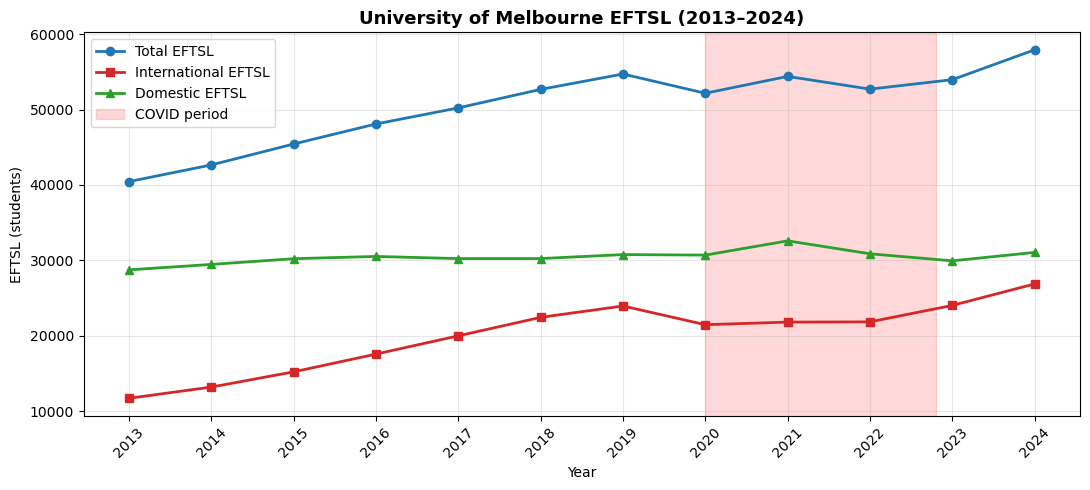

In [26]:

# Plot 1: EFTSL trends + EFTSL vs energy consumption

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(enrolment_lookup['year'], enrolment_lookup['total_eftsl'],
        marker='o', linewidth=2, label='Total EFTSL', color='#1f77b4')
ax.plot(enrolment_lookup['year'], enrolment_lookup['international_eftsl'],
        marker='s', linewidth=2, label='International EFTSL', color='#d62728')
ax.plot(enrolment_lookup['year'], enrolment_lookup['domestic_eftsl'],
        marker='^', linewidth=2, label='Domestic EFTSL', color='#2ca02c')

# Shade COVID period
ax.axvspan(2020, 2022.8, alpha=0.15, color='red', label='COVID period')

ax.set_title('University of Melbourne EFTSL (2013–2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('EFTSL (students)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
ax.set_xticks(enrolment_lookup['year'])
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

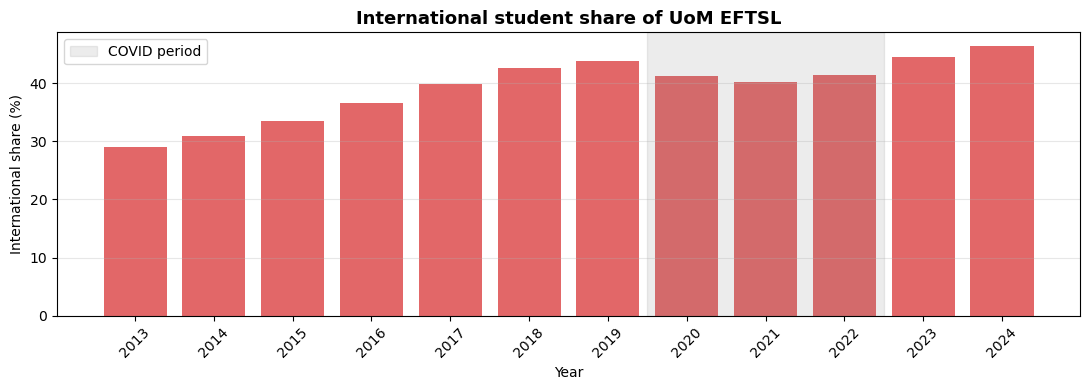

In [27]:
# Plot 2: International share of total EFTSL (over time)

fig, ax = plt.subplots(figsize=(11, 4))

ax.bar(enrolment_lookup['year'], enrolment_lookup['intl_share'] * 100,
       color='#d62728', alpha=0.7)
ax.axvspan(2019.5, 2022.5, alpha=0.15, color='gray', label='COVID period')

ax.set_title('International student share of UoM EFTSL', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('International share (%)')
ax.set_xticks(enrolment_lookup['year'])
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3, axis='y')
ax.legend()

plt.tight_layout()
plt.show()

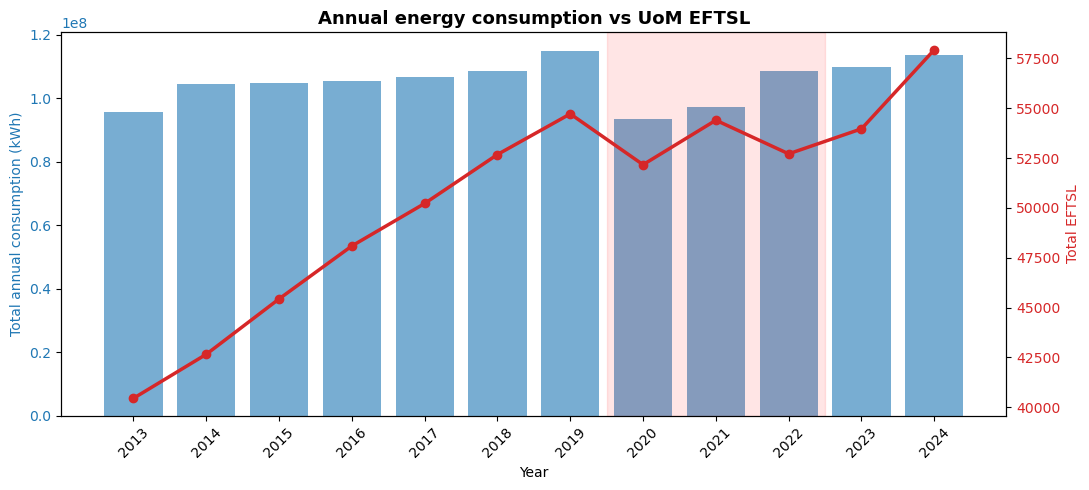

In [28]:
# Plot 3: Annual total consumption vs Annual EFTSL

# Aggregate half-hourly consumption to annual total (sum across all NMIs and time)
annual_consumption = (
    df.dropna(subset=['total_eftsl'])
      .set_index('date')
      .drop(columns=['year','total_eftsl','international_eftsl','domestic_eftsl',
                     'intl_share','eftsl_index_2019','intl_eftsl_index_2019',
                     'covid_period'], errors='ignore')
      .sum(axis=1, numeric_only=True)
      .resample('YE').sum()
      .to_frame(name='total_consumption_kwh')
)
annual_consumption['year'] = annual_consumption.index.year
annual_consumption = annual_consumption.merge(enrolment_lookup, on='year', how='left')

# Dual-axis plot: consumption + EFTSL
fig, ax1 = plt.subplots(figsize=(11, 5))

color1 = '#1f77b4'
ax1.set_xlabel('Year')
ax1.set_ylabel('Total annual consumption (kWh)', color=color1)
ax1.bar(annual_consumption['year'], annual_consumption['total_consumption_kwh'],
        color=color1, alpha=0.6, label='Total consumption')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(annual_consumption['year'])
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
color2 = '#d62728'
ax2.set_ylabel('Total EFTSL', color=color2)
ax2.plot(annual_consumption['year'], annual_consumption['total_eftsl'],
         color=color2, marker='o', linewidth=2.5, label='Total EFTSL')
ax2.tick_params(axis='y', labelcolor=color2)

# COVID shading
ax1.axvspan(2019.5, 2022.5, alpha=0.1, color='red')

plt.title('Annual energy consumption vs UoM EFTSL', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

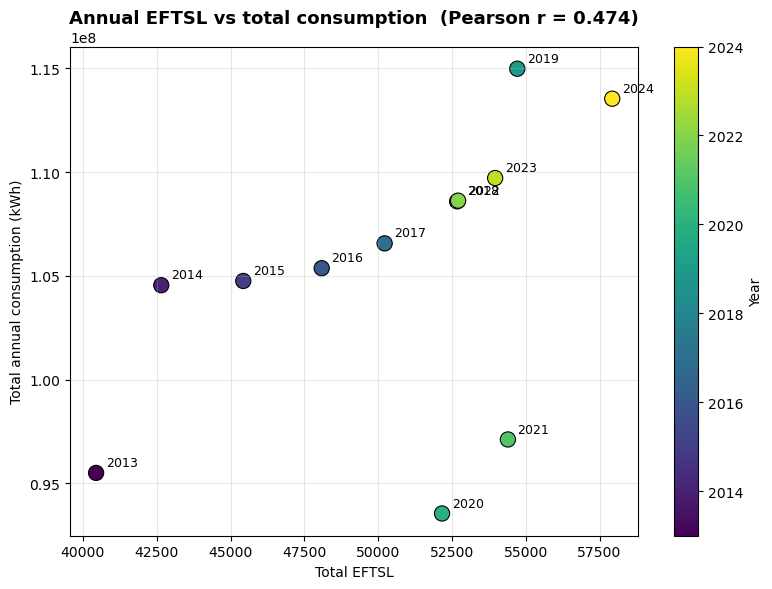

In [ ]:
# Plot 4: Check whether EFTSL correlates with consumption
fig, ax = plt.subplots(figsize=(8, 6))

# Color points by year so we can see the trajectory
scatter = ax.scatter(annual_consumption['total_eftsl'],
                     annual_consumption['total_consumption_kwh'],
                     c=annual_consumption['year'], cmap='viridis',
                     s=120, edgecolors='black', linewidth=0.8)

# Annotate each point with the year
for _, row in annual_consumption.iterrows():
    ax.annotate(int(row['year']),
                (row['total_eftsl'], row['total_consumption_kwh']),
                xytext=(7, 5), textcoords='offset points', fontsize=9)

# Compute and show correlation
corr = annual_consumption[['total_eftsl','total_consumption_kwh']].corr().iloc[0,1]
ax.set_title(f'Annual EFTSL vs total consumption  (Pearson r = {corr:.3f})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Total EFTSL')
ax.set_ylabel('Total annual consumption (kWh)')
ax.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Year')
plt.tight_layout()
plt.show()